# MovieLens 1M Matrix Factorization

This notebook summarizes the reproducible production pipeline comparing truncated SVD and a locally implemented biased probabilistic matrix factorization model.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
from utils.data_loader import load_movielens, validate_movielens

ROOT = Path.cwd()
data = load_movielens(ROOT / 'data')
summary = validate_movielens(data)
summary

{'n_users': 6040,
 'n_movies': 3883,
 'n_ratings': 1000209,
 'rating_distribution': {'1': 56174,
  '2': 107557,
  '3': 261197,
  '4': 348971,
  '5': 226310},
 'user_interactions': {'min': 20, 'median': 96.0, 'max': 2314},
 'movie_interactions': {'min': 1, 'median': 123.5, 'max': 3428},
 'matrix_sparsity': 0.9573532020200125}

## Data and split policy

Observed ratings are split independently per user with seed 42 into approximately 70% train, 15% validation, and 15% test. Every user retains training interactions, held-out movies are covered by train, validation selects hyperparameters, and test is evaluated once.

In [2]:
train = pd.read_csv(ROOT / 'processed/train_ratings.csv')
validation = pd.read_csv(ROOT / 'processed/validation_ratings.csv')
test = pd.read_csv(ROOT / 'processed/test_ratings.csv')
pd.DataFrame({'rows': [len(train), len(validation), len(test)]}, index=['train', 'validation', 'test'])

,rows
train,705806
validation,147201
test,147202


## Matrix normalization and SVD

The training user-item matrix stores only observed residuals after subtracting each user's observed training mean. Missing entries remain conceptually missing and are represented as sparse zeros for `scipy.sparse.linalg.svds`. Singular values are sorted descending before reconstruction; user means are then restored and predictions clipped to 1–5.

In [3]:
svd_tuning = pd.read_json(ROOT / 'reports/svd_tuning.json')
svd_tuning

,n_factors,item_bias_regularization,validation_rmse
0,5,0,0.903982
1,10,0,0.898577
2,20,0,0.896270
3,40,0,0.897152
4,60,0,0.899590
5,5,5,0.903823
6,10,5,0.898446
7,20,5,0.896209
8,40,5,0.897119
9,60,5,0.899539


## PMF

PMF uses a global mean, user and item biases, and latent factors trained only on observed ratings with seeded shuffled SGD. Early stopping and checkpoint restoration use validation RMSE only.

,n_factors,learning_rate,factor_regularization,bias_regularization,best_epoch,validation_rmse,epochs_run,seconds,hit_epoch_cap,hit_factor_boundary
7,128,0.006,0.06,0.02,53,0.849353,61,34.480,False,True
6,128,0.006,0.05,0.02,40,0.849747,48,27.421,False,True
4,112,0.006,0.06,0.02,53,0.849830,61,27.601,False,False
1,96,0.006,0.06,0.02,53,0.850033,61,25.100,False,False
8,128,0.006,0.07,0.02,68,0.850417,70,39.905,False,True


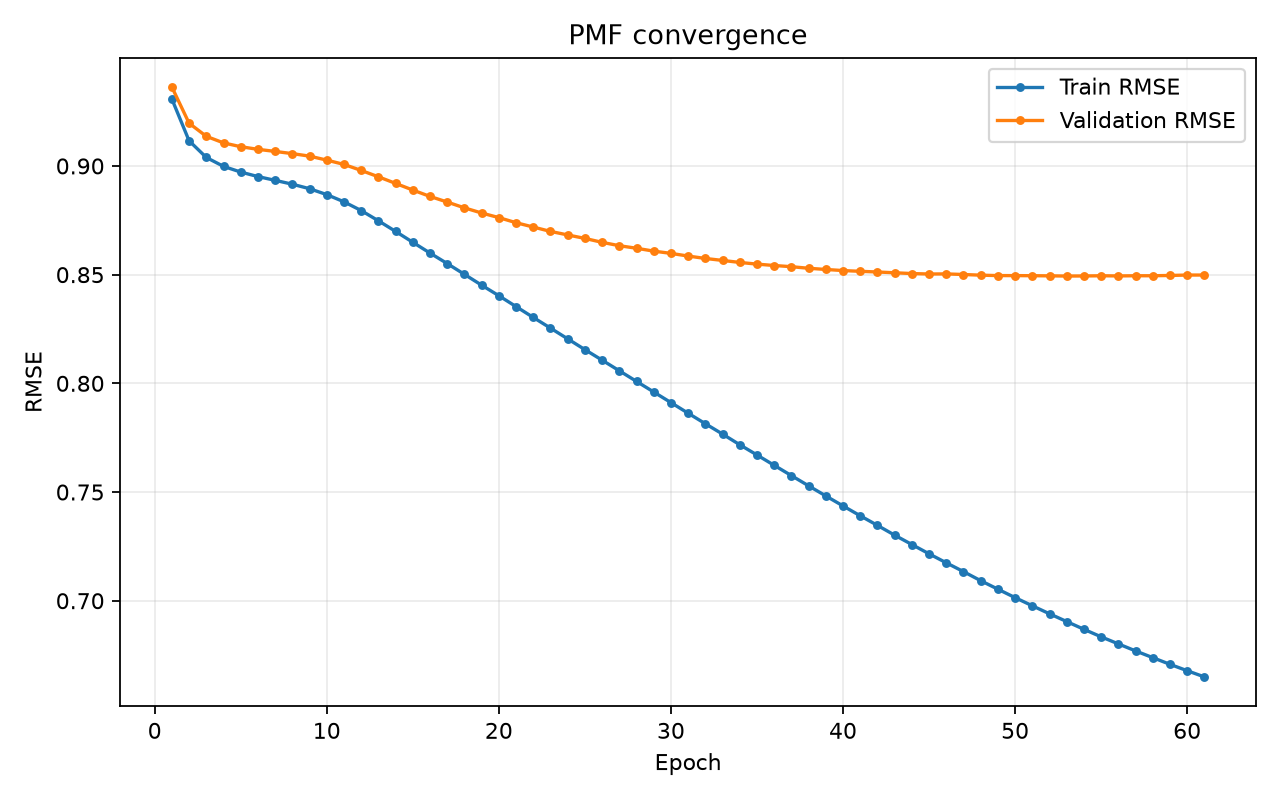

In [4]:
pmf_tuning = pd.read_json(ROOT / 'reports/pmf_tuning.json')
display(pmf_tuning.sort_values('validation_rmse').head())
display(Image(filename=str(ROOT / 'reports/pmf_convergence.png')))

## Final test comparison

In [5]:
with open(ROOT / 'reports/model_metrics.json', encoding='utf-8') as handle:
    metrics = json.load(handle)
metrics

{'random_state': 42,
 'split': {'train_ratio': 0.7,
  'validation_ratio': 0.15,
  'test_ratio': 0.15,
  'actual_counts': {'train': 705806, 'validation': 147201, 'test': 147202}},
 'SVD_MSE': 0.79351785357141,
 'SVD_RMSE': 0.890796190815503,
 'PMF_MSE': 0.7121652343689375,
 'PMF_RMSE': 0.8438988294629503,
 'PMF_vs_SVD_improvement_%': 5.264656701059678,
 'SVD_target_met': True,
 'PMF_target_met': True,
 'improvement_target_met': True,
 'svd_best_params': {'n_factors': 20, 'item_bias_regularization': 5.0},
 'pmf_best_params': {'n_factors': 128,
  'learning_rate': 0.006,
  'factor_regularization': 0.06,
  'bias_regularization': 0.02,
  'selected_epoch': 53,
  'validation_rmse': 0.8493525385856628},
 'pmf_search_diagnostics': {'selected_at_factor_boundary': True,
  'selected_at_epoch_boundary': False,
  'selected_early_stopping_triggered': True,
  'search_max_factors': 128,
  'search_max_epochs': 70}}

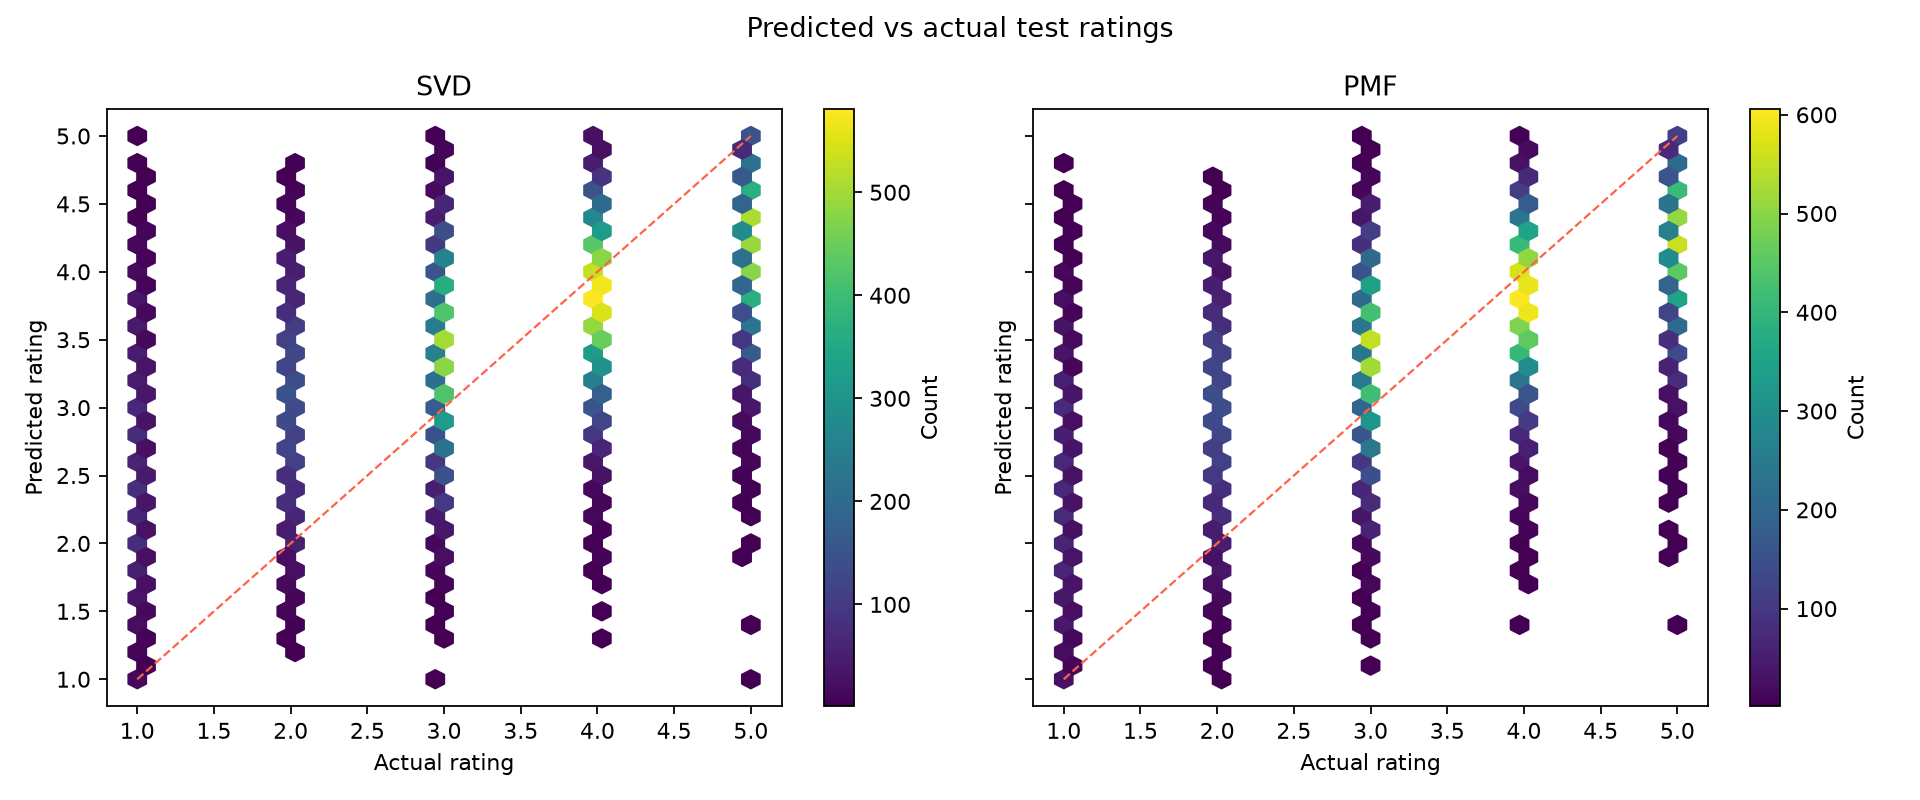

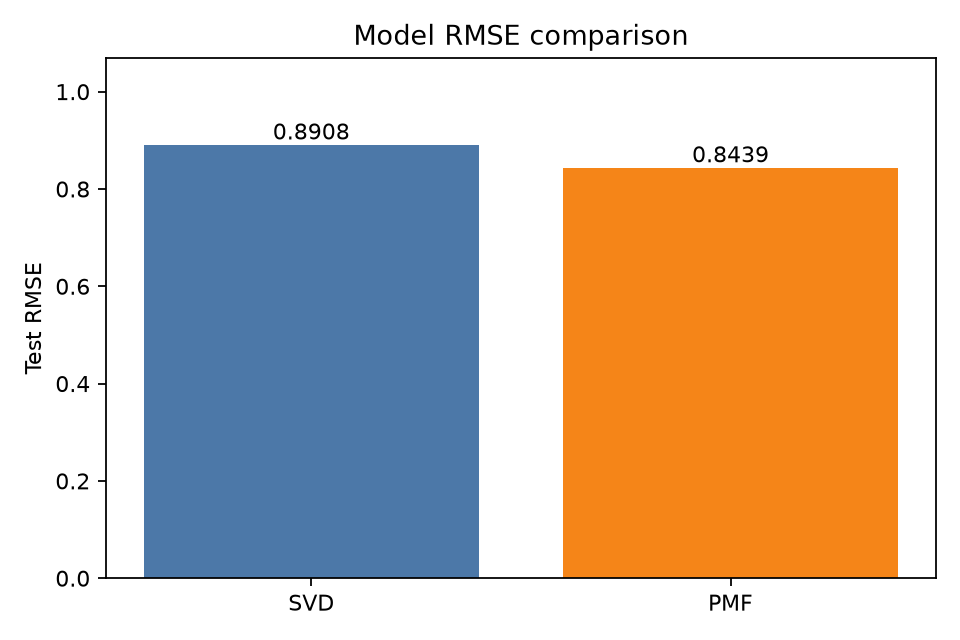

In [6]:
display(Image(filename=str(ROOT / 'reports/predicted_vs_actual.png')))
display(Image(filename=str(ROOT / 'reports/rmse_comparison.png')))

## Evaluated-user recommendations

Showcase users are selected automatically from train activity at the nearest 25th, 50th, and 75th percentiles, before inspecting recommendations.

In [7]:
with open(ROOT / 'reports/evaluated_users.json', encoding='utf-8') as handle:
    evaluated = json.load(handle)
display(pd.DataFrame(evaluated))
first_user = evaluated[0]['user_id']
pd.read_csv(ROOT / f'reports/user_{first_user}_recommendations.csv').head(15)

,quantile,target_train_count,user_id,train_ratings
0,0.25,32.0,91,32
1,0.50,68.0,40,68
2,0.75,146.0,1186,146


,movie_id,title,genres,svd_ranking_score,svd_predicted_rating,svd_rank,pmf_ranking_score,pmf_predicted_rating,pmf_rank
0,2905,Sanjuro (1962),Action|Adventure,5.497884,5.0,1.0,5.302402,5.0,3.0
1,318,"Shawshank Redemption, The (1994)",Drama,5.469182,5.0,2.0,5.305529,5.0,2.0
2,1148,"Wrong Trousers, The (1993)",Animation|Comedy,5.453482,5.0,3.0,5.170628,5.0,10.0
3,50,"Usual Suspects, The (1995)",Crime|Thriller,5.450618,5.0,4.0,NaN,NaN,NaN
4,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,5.449473,5.0,5.0,NaN,NaN,NaN
5,745,"Close Shave, A (1995)",Animation|Comedy|Thriller,5.445372,5.0,6.0,NaN,NaN,NaN
6,858,"Godfather, The (1972)",Action|Crime|Drama,5.404142,5.0,7.0,NaN,NaN,NaN
7,2762,"Sixth Sense, The (1999)",Thriller,5.401517,5.0,8.0,5.232602,5.0,6.0
8,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,5.394259,5.0,9.0,NaN,NaN,NaN
9,527,Schindler's List (1993),Drama|War,5.386427,5.0,10.0,5.223492,5.0,7.0


## Conclusion

The final metrics above come from the untouched test partition. PMF's bias terms and interaction-specific latent factors provide the stronger rating estimate, while SVD remains a compact deterministic spectral baseline. Both methods are limited to collaborative signals and cannot solve new-user cold start without side information.